# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [76]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


In [43]:
# fijo constantes

IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32
IMAGE_CHANNELS = 3
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)

BATCH_SIZE = 32
EPOCHS = 30

In [44]:
# rutas
ROOT_PATH = "C:/Users/titea/Downloads/clasificador_paisajes/"
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"


In [45]:
# función para cargar el dataset

# no uso la manera del de los perritos porque estas imágenes NO tienen la clase en el nombre
# las clases están en carpetas separadas

def cargar_imagenes(ruta_base):
    '''
    recorre las carpetas dentro de ruta_base
    cada carpeta representa una clase
    carga todas las imágenes, las redimensiona y devuelve X, y y class_names
    '''
    X = []
    y = []

    class_names = sorted(os.listdir(ruta_base))  # nombres de carpetas = clases

    for etiqueta, clase in enumerate(class_names):
        carpeta = os.path.join(ruta_base, clase)

        for archivo in os.listdir(carpeta): #recorrer todas las imágenes dentro de la carpeta
            img_path = os.path.join(carpeta, archivo)

            img = load_img(img_path, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT)) # carga imagen y redimensiona
            img_array = img_to_array(img)

            X.append(img_array)
            y.append(etiqueta)

    return np.array(X), np.array(y), class_names

In [46]:
X_train, y_train, class_names = cargar_imagenes(TRAIN_PATH)
X_test, y_test, _ = cargar_imagenes(TEST_PATH)


In [73]:
print(X_train.shape)
print(X_test.shape)

(14034, 32, 32, 3)
(3000, 32, 32, 3)


In [47]:
# no creo un dataset porque es distinto al de los perritos, no están todas las imágenes en una misma carpeta

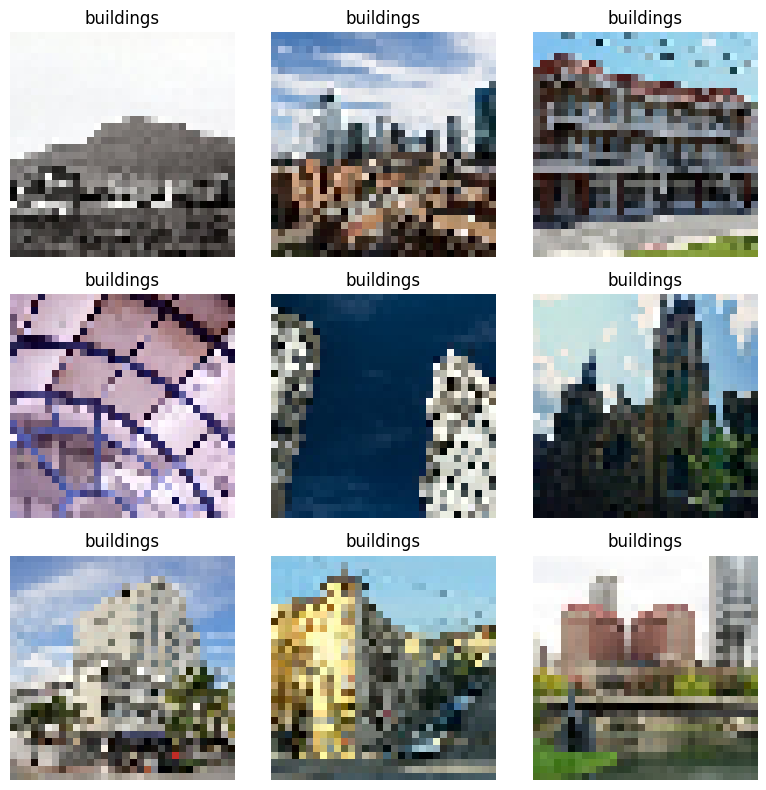

In [48]:
# visualizo muestra

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i].astype("uint8"))
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [49]:
# 3. normalización

In [ ]:
# normalizar a rango [0,1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [51]:
# 4. Dseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada

In [58]:
# modelo CNN sencillo
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=IMAGE_SIZE),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(class_names), activation='softmax')  # salida softmax
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# 5. Reserva un 20% de los datos del entrenamiento para validar.

In [59]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


In [54]:
# 6. Representa el objeto history

In [60]:
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=30,
    batch_size=32
)


Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5766 - loss: 1.0839 - val_accuracy: 0.6516 - val_loss: 0.9345
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6970 - loss: 0.8174 - val_accuracy: 0.7118 - val_loss: 0.7960
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7467 - loss: 0.7025 - val_accuracy: 0.7225 - val_loss: 0.7752
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7764 - loss: 0.6209 - val_accuracy: 0.7503 - val_loss: 0.6991
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7968 - loss: 0.5650 - val_accuracy: 0.7332 - val_loss: 0.7238
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8093 - loss: 0.5209 - val_accuracy: 0.7560 - val_loss: 0.6603
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8315 - loss: 0.4727 - val_accuracy: 0.7834 - val_loss: 0.6450
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8520 - loss: 0.4138 - val_accu

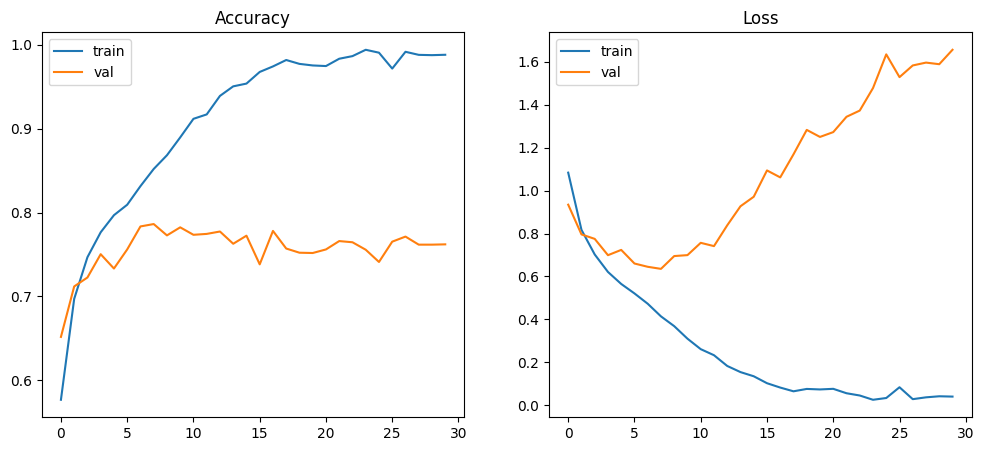

In [66]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [67]:
# 7. Evalua el modelo con los datos de test

In [68]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7490 - loss: 1.6849
Test accuracy: 0.7490000128746033


In [69]:
# 8. Representa algunos de los paisajes donde el modelo comete errores

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


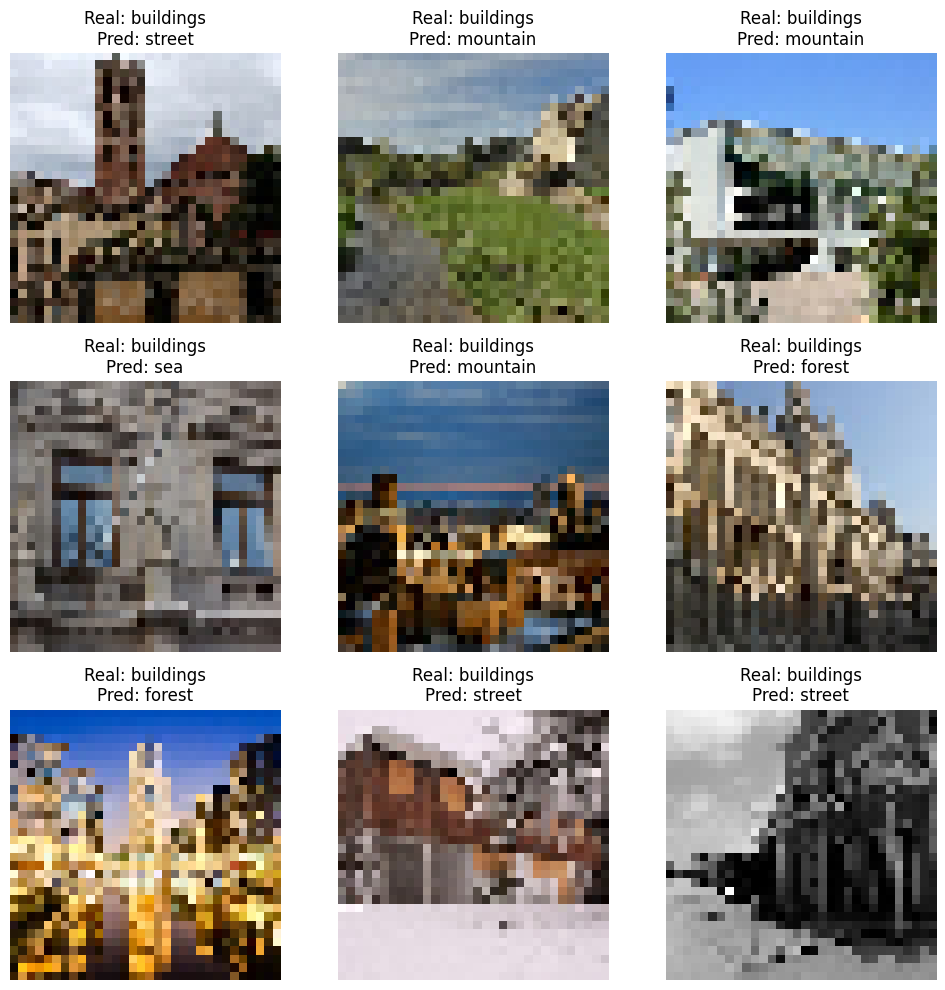

In [70]:
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=1)

errores = np.where(pred_labels != y_test)[0]

plt.figure(figsize=(10,10))
for i, idx in enumerate(errores[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[pred_labels[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [71]:

# 9. Crea una matriz de confusión con los errores del modelo

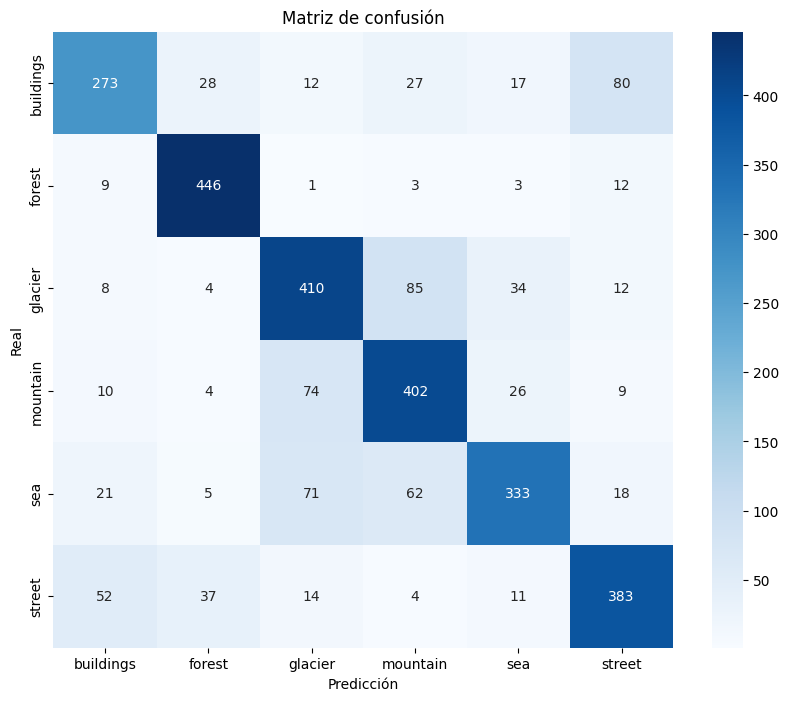

In [77]:

cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()
